# Bank Earnings-Call NLP Pipeline — Loading, Structuring & Exploratory Analysis

We can separate the project into stages.

**Stage 1 — Collect**
Find suitable quarterly results material for one or two G-SIBs (Global Systemically Important Banks).

**Stage 2 — Structure**
Turn documents or transcripts into a consistent dataset.

**Stage 3 — Understand**
Explore coverage, speakers, sections, text lengths and data quality.

**Stage 4 — Extract signals** *(later notebook)*
Apply methods such as topic identification, financial sentiment analysis, keyword / metric extraction, summarisation.

**Stage 5 — Compare** *(later notebook)*
Compare topics within a bank, quarters within a bank, analysts versus management, one bank against a peer.

**Stage 6 — Interpret** *(later notebook)*
Ask whether the extracted information could genuinely provide additional insight into the firm's risk profile. A technically interesting NLP model is not automatically a useful regulatory insight.

---

**This notebook covers the hand-off from Stage 1 through Stage 2 and Stage 3.** Stage 1 (collection of the JPM and UBS transcripts into `all_sentences.csv`, `all_utterances.csv` and `all_metrics.csv`) has already happened upstream of this notebook. What follows here is:

1. Load the raw extracted CSVs and do a first sanity check that the upload actually worked.
2. Run exploratory data analysis on the raw data.
3. Build a small, reusable **Stage 2 structuring pipeline** (a handful of pure functions) that turns the raw tables into a clean, well-keyed dataset.
4. Run a confirmatory **Stage 3 pass** on the *structured* output, so anyone else on the team picking this up can trust it before it is used for topic modelling or sentiment analysis in Stage 4.

The structured CSVs this notebook produces (`structured_sentences.csv`, `structured_utterances.csv`, `qa_exchanges_utterance_level.csv`) are the hand-off artefact for the rest of the team.

# Setup

In [151]:
import sys
import os
import pathlib
import pandas as pd
import re

# Visual libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [152]:
#-----------------------------------------------------------------------------------
# Properly add the project root to the path so python can find 'src'
#-----------------------------------------------------------------------------------
root_str = os.path.abspath(os.path.join('..', '..'))
if root_str not in sys.path:
    sys.path.insert(0, root_str)

In [153]:
#-----------------------------------------------------------------------------------
# Convert the root string into a real pathlib Path object
#-----------------------------------------------------------------------------------

project_root = pathlib.Path(root_str)

In [154]:
#-----------------------------------------------------------------------------------
# Point DATA strictly to your local "data" directory
#-----------------------------------------------------------------------------------

DATA = project_root / "data"

## Load the raw data

We load the three raw tables produced by Stage 1: sentence-level, utterance-level (one row per
speaker turn) and metrics (reported financial figures per call). All three are keyed on a
particular export snapshot date, `EXPORT`, so that re-running this notebook later against a newer
extraction does not silently change the numbers under us.

In [155]:
from src import loading

In [156]:
EXPORT = "2026-09-13"

raw_utterances = loading.load(DATA, "all_utterances.csv", EXPORT)
raw_sentences = loading.load(DATA, "all_sentences.csv", EXPORT)
raw_metrics = loading.load(DATA, "all_metrics.csv", EXPORT)

loaded all_utterances.csv  1201 rows
loaded all_sentences.csv  9519 rows
loaded all_metrics.csv  510 rows


### Initial check — did the upload / extraction actually work?

Before doing any real analysis, we want a cheap sanity check: right shapes, right columns,
nothing obviously empty or mistyped. This is not EDA yet, it is just "did the file we expected
land correctly."

In [161]:
print("Shapes:")
print(f"  metrics:    {raw_metrics.shape}")
print(f"  sentences:  {raw_sentences.shape}")
print(f"  utterances: {raw_utterances.shape}")

print("\nColumns:")
print(f"  metrics:    {list(raw_metrics.columns)}")
print(f"  sentences:  {list(raw_sentences.columns)}")
print(f"  utterances: {list(raw_utterances.columns)}")

print("\nFirst couple of rows of each, just to eyeball that parsing looks sane:")
print("\n--------------------------------- metrics.head() --------------------------")
print(raw_metrics.head(2))
print("\n----------------------------------- sentences.head() -----------------------------------")
print(raw_sentences.head(2))
print("\n----------------------------------- utterances.head() -----------------------------------")
print(raw_utterances.head(2))

Shapes:
  metrics:    (510, 6)
  sentences:  (9519, 12)
  utterances: (1201, 11)

Columns:
  metrics:    ['bank', 'quarter', 'metric_name', 'value', 'unit', 'basis']
  sentences:  ['bank', 'quarter', 'call_type', 'call_date', 'position_in_call', 'section', 'speaker_role', 'speaker_name', 'speaker_institution', 'sentence_id', 'sentence_number', 'sentence']
  utterances: ['bank', 'quarter', 'call_type', 'call_date', 'position_in_call', 'section', 'speaker_role', 'speaker_name', 'speaker_institution', 'text_length', 'text']

First couple of rows of each, just to eyeball that parsing looks sane:

--------------------------------- metrics.head() --------------------------
  bank  quarter             metric_name   value     unit     basis
0  JPM  2023-Q1    average_shares_basic  2968.5  count m  reported
1  JPM  2023-Q1  average_shares_diluted  2972.7  count m  reported

----------------------------------- sentences.head() -----------------------------------
  bank  quarter call_type   call_

In [162]:
#----------------------------------------------------------------------------------------
# dtypes + missing-value counts: a quick structural check before we trust the data enough
# to explore it properly.
#----------------------------------------------------------------------------------------
for name, df in zip(["Metrics", "Sentences", "Utterances"], [raw_metrics, raw_sentences, raw_utterances]):
    print(f"\n=== {name} ===")
    print(df.dtypes)
    print(f"\nMissing values in {name}:")
    print(df.isnull().sum())


=== Metrics ===
bank            object
quarter         object
metric_name     object
value          float64
unit            object
basis           object
dtype: object

Missing values in Metrics:
bank           0
quarter        0
metric_name    0
value          0
unit           0
basis          0
dtype: int64

=== Sentences ===
bank                   object
quarter                object
call_type              object
call_date              object
position_in_call        int64
section                object
speaker_role           object
speaker_name           object
speaker_institution    object
sentence_id             int64
sentence_number         int64
sentence               object
dtype: object

Missing values in Sentences:
bank                      0
quarter                   0
call_type                 0
call_date                 0
position_in_call          0
section                   0
speaker_role              0
speaker_name              0
speaker_institution    7133
sentence_id  

## Stage 3: Understand (diagnostic pass, on the raw data)

### What would we want to know about the data?

Once transcripts have been collected, our first job should be ordinary exploratory data analysis.

For example:

**Coverage**
- Which banks do we have?
- Which quarters do we have?
- Are there gaps?

**Document structure**
- Can we distinguish prepared remarks from Q&A?
- Can we identify individual speakers?
- Can we distinguish analysts from management?

**Volume**
- How long are transcripts?
- How many questions are asked each quarter?
- Does transcript length vary substantially between banks?

**Text quality**
- Are speaker labels reliable?
- Are tables or page headers mixed into the extracted text?
- Are there duplicated passages?
- Are there unusual characters or formatting problems?

These checks should come before topic modelling or sentiment analysis. Run at the raw-data
stage, they are also what tell us *what the Stage 2 structuring pipeline needs to fix* — three
findings below (an extra non-earnings call, a duplicated-speaker edge case, and a text-mangling
bug found later during a reconciliation check) directly shape the functions built further down.

### Coverage: which banks, which quarters, are there gaps?

In [163]:
print("Banks present:", sorted(raw_sentences.bank.unique()))
print("Quarters present:", sorted(raw_sentences.quarter.unique()))

print("\nRow counts by bank x quarter (sentences):")
print(raw_sentences.groupby(["bank", "quarter"]).size())

print("\nDistinct call_date values per bank/quarter — should be exactly 1 unless a bank held")
print("an extra, non-routine call that quarter:")
print(raw_sentences.groupby(["bank", "quarter"]).call_date.nunique())
print(raw_sentences.groupby(["bank", "quarter"]).call_type.unique())

Banks present: ['JPM', 'UBS']
Quarters present: ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4']

Row counts by bank x quarter (sentences):
bank  quarter
JPM   2023-Q1    557
      2023-Q2    900
      2023-Q3    569
      2023-Q4    462
      2024-Q1    641
      2024-Q2    505
      2024-Q3    665
      2024-Q4    506
UBS   2023-Q1    539
      2023-Q2    672
      2023-Q3    534
      2023-Q4    804
      2024-Q1    501
      2024-Q2    447
      2024-Q3    508
      2024-Q4    709
dtype: int64

Distinct call_date values per bank/quarter — should be exactly 1 unless a bank held
an extra, non-routine call that quarter:
bank  quarter
JPM   2023-Q1    1
      2023-Q2    2
      2023-Q3    1
      2023-Q4    1
      2024-Q1    1
      2024-Q2    1
      2024-Q3    1
      2024-Q4    1
UBS   2023-Q1    1
      2023-Q2    1
      2023-Q3    1
      2023-Q4    1
      2024-Q1    1
      2024-Q2    1
      2024-Q3    1
      2024-Q4    1
Name: call_da

**Finding:** JPM 2023-Q2 has *two* calls, not one, the extra `call_type == "event"` row is
the First Republic acquisition call, not a routine quarterly earnings call. It is genuine
coverage, but pooling it with the routine earnings calls would distort any quarter-over-quarter
comparison later. We look at it directly below, then tag it explicitly in the Stage 2 pipeline
rather than dropping it.

In [164]:
ev = raw_sentences[raw_sentences.call_type == "event"]
print("Sections present in the event call:", ev.section.unique())
print("Speaker roles present in the event call:", ev.speaker_role.unique())
print("Call date(s):", ev.call_date.unique())
print("\nSample sentences:")
print(ev.sentence.head(5).to_list())

Sections present in the event call: ['prepared' 'qa']
Speaker roles present in the event call: ['operator' 'management' 'analyst']
Call date(s): ['2023-05-01']

Sample sentences:
['Good morning, ladies and gentlemen.', "Welcome to JPMorgan Chase's Conference Call.", 'This call is being recorded.', 'Your line will be muted for the duration of the call.', 'We will now go to the live presentation.']


### Document structure: prepared remarks vs. Q&A, individual speakers, analysts vs. management

In [165]:
print("call_type values:", raw_sentences.call_type.unique())
print("section values:", raw_sentences.section.unique())
print("speaker_role values:", raw_sentences.speaker_role.unique())

print("\nsection x speaker_role crosstab (sentences):")
print(pd.crosstab(raw_sentences.section, raw_sentences.speaker_role))

print("\nUnique speaker_name count by role:")
print(raw_sentences.groupby("speaker_role").speaker_name.nunique())

print("\nAnalyst speaker_institution fill rate (do we know which sell-side firm each analyst is from?):")
an = raw_sentences[raw_sentences.speaker_role == "analyst"]
print(f"  {an.speaker_institution.isnull().mean():.1%} null; {an.speaker_institution.nunique()} unique institutions")
print(an.speaker_institution.dropna().unique()[:20])

call_type values: ['earnings' 'event']
section values: ['prepared' 'qa']
speaker_role values: ['operator' 'management' 'analyst' 'ir']

section x speaker_role crosstab (sentences):
speaker_role  analyst  ir  management  operator
section                                        
prepared            0   0        2926        77
qa               2386   5        3857       268

Unique speaker_name count by role:
speaker_role
analyst       34
ir             1
management     5
operator       1
Name: speaker_name, dtype: int64

Analyst speaker_institution fill rate (do we know which sell-side firm each analyst is from?):
  0.0% null; 26 unique institutions
['Wolfe Research' 'Jefferies' 'Autonomous Research' 'UBS'
 'Seaport Global Securities' 'RBC Capital Markets' 'Bank of America'
 'Wells Fargo Securities' 'Morgan Stanley' 'Evercore ISI' 'Deutsche Bank'
 'Piper Sandler' 'Portales Partners' 'HSBC Securities' 'Truist Securities'
 'Goldman Sachs' 'JPMorgan' 'Citi' 'Mediobanca' 'BNP Paribas Exane']


**Finding:** `section` cleanly distinguishes prepared remarks from Q&A, and `speaker_role`
cleanly distinguishes analyst from management, so both of those checklist items are answered by
columns we already have. What is *not* directly usable is a stable per-call
"utterance id": the raw data only has `position_in_call`. We will need to deal with this later on in the process.

There is also a subtler issue worth flagging that we've come across, because it only shows up once we try to group
Q&A turns into exchanges: two different analysts can speak back-to-back with no management turn
in between (e.g. one analyst's closing "Thank you." immediately followed by a different analyst's
real question). A naive rule of "new exchange whenever `speaker_role` becomes `analyst`" would
silently merge those two people's questions into one exchange. We build the fix for this later on in the process, 
provisionally to be called: `build_qa_exchanges` (TBC)

### Volume: transcript length & how it varies

In [166]:
print("--- Metrics: numerical summary ---")
print(raw_metrics.describe())

--- Metrics: numerical summary ---
              value
count  5.100000e+02
mean   2.151544e+05
std    6.422114e+05
min   -7.850000e+02
25%    1.643500e+01
50%    1.404500e+03
75%    4.228425e+04
max    4.210048e+06


In [ ]:
#----------------------------------------------------------------------
# Sentence-level length metrics (words / characters per sentence)
#----------------------------------------------------------------------
raw_sentences["word_count"] = raw_sentences["sentence"].apply(lambda x: len(str(x).split()))
raw_sentences["char_count"] = raw_sentences["sentence"].apply(lambda x: len(str(x)))
print("--- Sentence text metrics ---")
print(raw_sentences[["word_count", "char_count"]].describe())

--- Sentence text metrics ---
        word_count   char_count
count  9519.000000  9519.000000
mean     18.190146   104.836537
std      13.775860    80.390964
min       1.000000     3.000000
25%       7.000000    40.000000
50%      16.000000    91.000000
75%      26.000000   153.500000
max     139.000000   809.000000


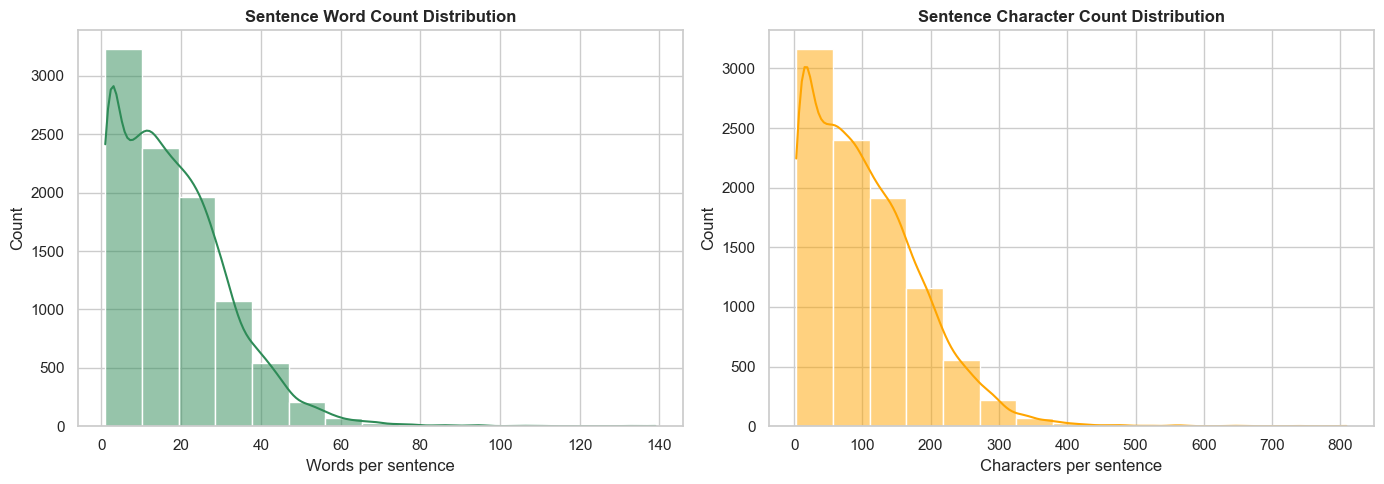

In [171]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(raw_sentences["word_count"], bins=15, kde=True, ax=axes[0], color="seagreen")
axes[0].set_title("Sentence Word Count Distribution", fontweight="bold")
axes[0].set_xlabel("Words per sentence")

sns.histplot(raw_sentences["char_count"], bins=15, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Sentence Character Count Distribution", fontweight="bold")
axes[1].set_xlabel("Characters per sentence")

plt.tight_layout()
plt.show()

In [168]:
#-------------------------------------------------------------------------
# Utterance-level length metrics (words / characters per speaker turn)
#-------------------------------------------------------------------------
raw_utterances["word_count"] = raw_utterances["text"].apply(lambda x: len(str(x).split()))
raw_utterances["char_count"] = raw_utterances["text"].apply(lambda x: len(str(x)))
print("--- Utterance text metrics ---")
print(raw_utterances[["word_count", "char_count"]].describe())
print("\nUtterance length by section (prepared remarks vs. Q&A tend to differ a lot):")
print(raw_utterances.groupby("section").text_length.describe())

--- Utterance text metrics ---
        word_count    char_count
count  1201.000000   1201.000000
mean    144.173189    837.849292
std     374.612655   2349.122331
min       1.000000      3.000000
25%       7.000000     40.000000
50%      61.000000    332.000000
75%     156.000000    861.000000
max    4657.000000  30076.000000

Utterance length by section (prepared remarks vs. Q&A tend to differ a lot):
           count         mean          std   min     25%     50%       75%  \
section                                                                      
prepared    43.0  9448.023256  8275.038833  43.0  697.50  9778.0  13411.00   
qa        1158.0   518.127807   616.585543   3.0   37.25   296.5    823.25   

              max  
section            
prepared  30076.0  
qa         4404.0  


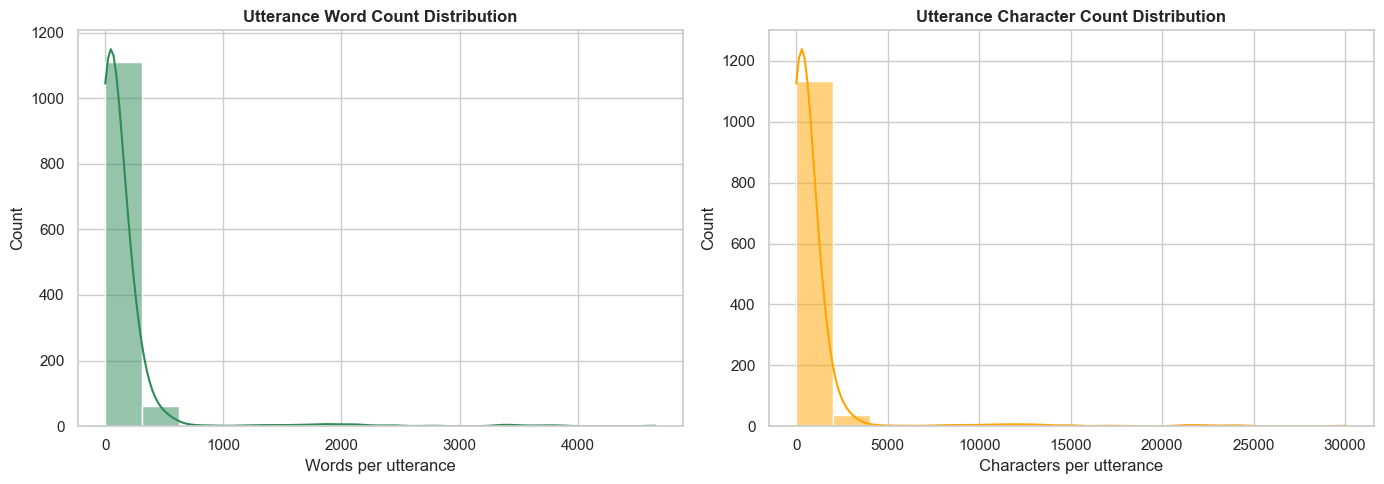

In [172]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(raw_utterances["word_count"], bins=15, kde=True, ax=axes[0], color="seagreen")
axes[0].set_title("Utterance Word Count Distribution", fontweight="bold")
axes[0].set_xlabel("Words per utterance")

sns.histplot(raw_utterances["char_count"], bins=15, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Utterance Character Count Distribution", fontweight="bold")
axes[1].set_xlabel("Characters per utterance")

plt.tight_layout()
plt.show()

**Finding:** utterances are noticeably longer than individual sentences (as expected, an
utterance is made of several sentences), and Q&A-section utterances behave differently from
prepared-remarks ones. The real question of "does length vary between banks" is better asked on
the *structured*, deduplicated data further down, once we get an handle on : `is_routine_earnings` which we can the use to compare like
with like.

### Text quality: speaker labels, duplicated passages, formatting artefacts

In [ ]:
#------------------------------------------------------------------------------------------------------
# Exact-duplicate sentence rows within the same call: a cheap first pass at "does the same
# passage appear twice", which can happen if page headers/footers or repeated boilerplate slipped
# into the extraction.
#--------------------------------------------------------------------------------------------------------
dup_rate = raw_sentences.duplicated(subset=["bank", "quarter", "call_date", "sentence"]).mean()
print(f"Exact duplicate sentence rows within the same call: {dup_rate:.2%}")
print("(non-zero doesn't necessarily mean a bug -- short filler lines like 'Thank you.' genuinely")
print(" repeat -- but a high rate is worth a manual look for header/footer contamination.)")

Exact duplicate sentence rows within the same call: 8.52%
(non-zero doesn't necessarily mean a bug -- short filler lines like 'Thank you.' genuinely
 repeat -- but a high rate is worth a manual look for header/footer contamination.)
